# Skill Analysis and NLP

## Job Market Skill Demand Analysis

**Project:** A Data-Driven Job Market Skill Demand Analysis and Career Recommendation System Using NLP and Machine Learning

This notebook analyzes the skills required across different career roles and prepares job description text for Natural Language Processing (NLP).

### Objectives

- Analyze the frequency of skills demanded in job postings.
- Identify the most important skills for different career roles.
- Examine relationships between careers and required skills.
- Process job description text using NLP techniques.
- Prepare text and skill features for the career recommendation system.

### 1. Import Libraries 

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Load Processed Dataset

In [14]:
df = pd.read_csv("../data/job_postings_processed.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (15000, 19)


In [15]:
df.head()

,job_id,title,company,location,remote_type,industry,company_size,experience_level,salary_min,salary_max,required_skills,education_required,description,posted_date,applications,days_to_fill,skill_count,salary_avg,year
0,JOB13473,Data Scientist,PolicyData Corp,"Pittsburgh, PA",onsite,government,startup,senior,138000,164000,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,bachelor,Join PolicyData Corp as a senior Data Scientis...,2023-01-01,26,61,7,151000.0,2023
1,JOB10866,Data Engineer,LearnEdge Systems,"Omaha, NE",remote,education,medium,mid,85000,103000,Python|PostgreSQL|BigQuery|Spark,bachelor,LearnEdge Systems is looking for a passionate ...,2023-01-01,75,55,4,94000.0,2023
2,JOB12905,Product Manager,Keystone Public Analytics,"Albuquerque, NM",hybrid,government,startup,entry,63000,77000,User Research|JIRA,bachelor,Join Keystone Public Analytics as a entry Prod...,2023-01-01,22,34,2,70000.0,2023
3,JOB01986,Research Scientist,Quantum Leap Digital,"Albuquerque, NM",onsite,tech,startup,entry,61000,71000,PyTorch|Statistics,bachelor,Quantum Leap Digital is looking for a passiona...,2023-01-01,18,37,2,66000.0,2023
4,JOB07952,Backend Engineer,Fabricate AI,"Albuquerque, NM",onsite,manufacturing,large,director,208000,245000,Python|PostgreSQL|Redis|Java|Docker|REST APIs|...,master,As a director Backend Engineer at Fabricate AI...,2023-01-01,131,114,9,226500.0,2023


### 3. Understanding the Required Skills Field



In [16]:
# Check for missing skill values

df['required_skills'].isna().sum()

np.int64(0)

In [17]:
# Display several skill combinations

df['required_skills'].head(10).tolist()

['Jupyter|Deep Learning|Python|Statistics|NLP|SQL|A/B Testing',
 'Python|PostgreSQL|BigQuery|Spark',
 'User Research|JIRA',
 'PyTorch|Statistics',
 'Python|PostgreSQL|Redis|Java|Docker|REST APIs|Go|gRPC|SQL',
 'Jenkins|CI/CD|Grafana|Terraform|AWS|Azure|Ansible|Kubernetes',
 'REST APIs|Python|Go|gRPC|Redis',
 'Experimentation|Deep Learning|Python|Statistics|TensorFlow|Machine Learning|Publication Record',
 'TypeScript|C++|Go|Docker|Kubernetes|Redis',
 'Kubernetes|Kafka|Java|AWS']

In [18]:
# Summary of skills required per job posting

df['skill_count'].describe()

count    15000.000000
mean         5.824533
std          1.997234
min          2.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: skill_count, dtype: float64

In [19]:
skill_count_distribution = df['skill_count'].value_counts().sort_index()

skill_count_distribution

skill_count
2     1006
3     1040
4     2442
5     1434
6     3119
7     2428
8     2382
9      958
10     191
Name: count, dtype: int64

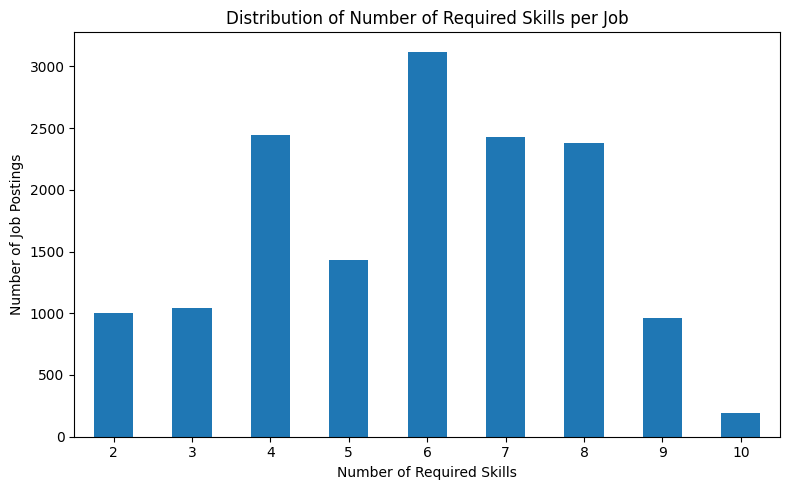

In [20]:
plt.figure(figsize=(8, 5))

skill_count_distribution.plot(kind='bar')

plt.title('Distribution of Number of Required Skills per Job')
plt.xlabel('Number of Required Skills')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### ## 4. Skill Extraction and Frequency Analysis

In [21]:
# Split required skills and create individual skill records

skills = (
    df['required_skills']
    .str.split('|')
    .explode()
    .str.strip()
)

skills.head(20)

0          Jupyter
0    Deep Learning
0           Python
0       Statistics
0              NLP
0              SQL
0      A/B Testing
1           Python
1       PostgreSQL
1         BigQuery
1            Spark
2    User Research
2             JIRA
3          PyTorch
3       Statistics
4           Python
4       PostgreSQL
4            Redis
4             Java
4           Docker
Name: required_skills, dtype: object

In [22]:
print("Total skill records:", len(skills))
print("Unique skills:", skills.nunique())

Total skill records: 87368
Unique skills: 69


In [24]:
# Count the frequency of each skill

skill_frequency = skills.value_counts()

skill_frequency.head(20)

required_skills
Python              5873
SQL                 4363
Docker              2675
Kubernetes          2673
AWS                 2672
Statistics          2454
A/B Testing         2432
TensorFlow          2330
PyTorch             2304
Spark               2064
PostgreSQL          1911
User Research       1893
Figma               1869
Machine Learning    1574
Deep Learning       1550
dbt                 1547
Tableau             1482
Airflow             1403
CI/CD               1394
Kafka               1388
Name: count, dtype: int64

In [25]:
# Create the skill demand dataframe

skill_demand = pd.DataFrame({
    'Skill': skill_frequency.index,
    'Job_Postings': skill_frequency.values
})

skill_demand['Demand_Percentage'] = (
    skill_demand['Job_Postings'] / len(df) * 100
).round(2)

skill_demand.head(20)

,Skill,Job_Postings,Demand_Percentage
0,Python,5873,39.15
1,SQL,4363,29.09
2,Docker,2675,17.83
3,Kubernetes,2673,17.82
4,AWS,2672,17.81
5,Statistics,2454,16.36
6,A/B Testing,2432,16.21
7,TensorFlow,2330,15.53
8,PyTorch,2304,15.36
9,Spark,2064,13.76


In [26]:
# Split required skills and create individual skill records

skills = (
    df['required_skills']
    .str.split('|')
    .explode()
    .str.strip()
)

print("Total skill records:", len(skills))
print("Unique skills:", skills.nunique())

Total skill records: 87368
Unique skills: 69


### 5. Top 20 Most In-Demand Skills

In [27]:
# Select the top 20 most demanded skills

top_20_skills = skill_demand.head(20)

top_20_skills

,Skill,Job_Postings,Demand_Percentage
0,Python,5873,39.15
1,SQL,4363,29.09
2,Docker,2675,17.83
3,Kubernetes,2673,17.82
4,AWS,2672,17.81
5,Statistics,2454,16.36
6,A/B Testing,2432,16.21
7,TensorFlow,2330,15.53
8,PyTorch,2304,15.36
9,Spark,2064,13.76


<Figure size 1000x700 with 0 Axes>

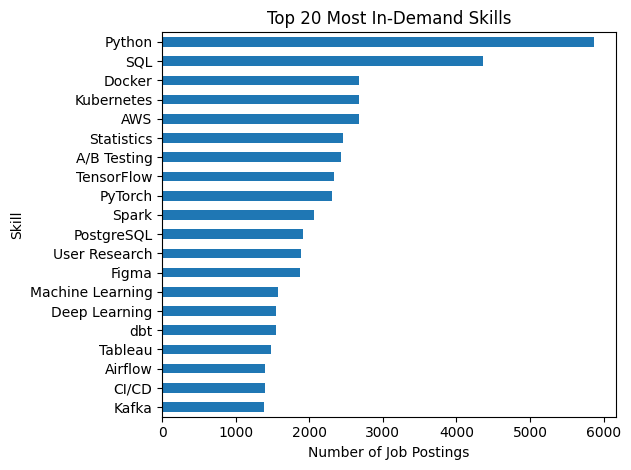

In [28]:
plt.figure(figsize=(10, 7))

top_20_skills.sort_values('Job_Postings').plot(
    x='Skill',
    y='Job_Postings',
    kind='barh',
    legend=False
)

plt.title('Top 20 Most In-Demand Skills')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')

plt.tight_layout()
plt.show()

<Figure size 1000x700 with 0 Axes>

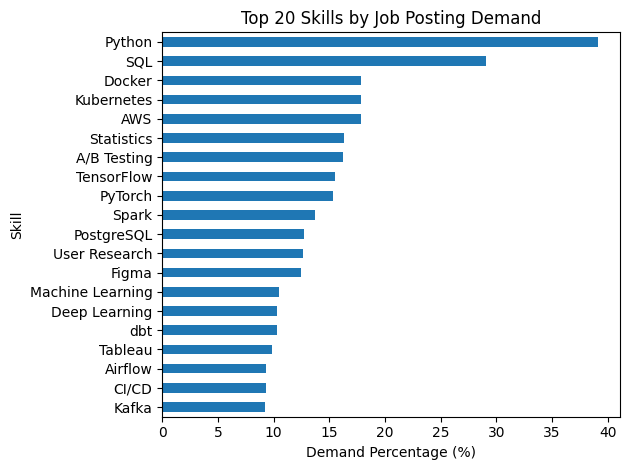

In [29]:
plt.figure(figsize=(10, 7))

top_20_skills.sort_values('Demand_Percentage').plot(
    x='Skill',
    y='Demand_Percentage',
    kind='barh',
    legend=False
)

plt.title('Top 20 Skills by Job Posting Demand')
plt.xlabel('Demand Percentage (%)')
plt.ylabel('Skill')

plt.tight_layout()
plt.show()

### 6. Career-wise Skill Demand Analysis

In [30]:
# Calculate skill demand for each career

career_skill_demand = (
    df[['title', 'required_skills']]
    .assign(
        Skill=df['required_skills'].str.split('|')
    )
    .explode('Skill')
)

career_skill_demand['Skill'] = (
    career_skill_demand['Skill']
    .str.strip()
)

career_skill_demand.head(20)

,title,required_skills,Skill
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,Jupyter
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,Deep Learning
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,Python
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,Statistics
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,NLP
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,SQL
0,Data Scientist,Jupyter|Deep Learning|Python|Statistics|NLP|SQ...,A/B Testing
1,Data Engineer,Python|PostgreSQL|BigQuery|Spark,Python
1,Data Engineer,Python|PostgreSQL|BigQuery|Spark,PostgreSQL
1,Data Engineer,Python|PostgreSQL|BigQuery|Spark,BigQuery


In [31]:
# Count how frequently each skill appears within each career

career_skill_counts = (
    career_skill_demand
    .groupby(['title', 'Skill'])
    .size()
    .reset_index(name='Job_Postings')
)

career_skill_counts.head(20)

,title,Skill,Job_Postings
0,Backend Engineer,AWS,710
1,Backend Engineer,Docker,687
2,Backend Engineer,Go,693
3,Backend Engineer,Java,733
4,Backend Engineer,Kafka,722
5,Backend Engineer,Kubernetes,687
6,Backend Engineer,PostgreSQL,706
7,Backend Engineer,Python,727
8,Backend Engineer,REST APIs,678
9,Backend Engineer,Redis,722


In [32]:
# Calculate percentage demand within each career

career_totals = (
    df['title']
    .value_counts()
    .rename('Total_Jobs')
    .reset_index()
)

career_totals.columns = ['title', 'Total_Jobs']

career_skill_counts = career_skill_counts.merge(
    career_totals,
    on='title',
    how='left'
)

career_skill_counts['Demand_Percentage'] = (
    career_skill_counts['Job_Postings'] /
    career_skill_counts['Total_Jobs'] * 100
).round(2)

career_skill_counts.head(20)

,title,Skill,Job_Postings,Total_Jobs,Demand_Percentage
0,Backend Engineer,AWS,710,1463,48.53
1,Backend Engineer,Docker,687,1463,46.96
2,Backend Engineer,Go,693,1463,47.37
3,Backend Engineer,Java,733,1463,50.10
4,Backend Engineer,Kafka,722,1463,49.35
5,Backend Engineer,Kubernetes,687,1463,46.96
6,Backend Engineer,PostgreSQL,706,1463,48.26
7,Backend Engineer,Python,727,1463,49.69
8,Backend Engineer,REST APIs,678,1463,46.34
9,Backend Engineer,Redis,722,1463,49.35


In [33]:
data_scientist_skills = (
    career_skill_counts[
        career_skill_counts['title'] == 'Data Scientist'
    ]
    .sort_values('Demand_Percentage', ascending=False)
)

data_scientist_skills.head(10)

,title,Skill,Job_Postings,Total_Jobs,Demand_Percentage
48,Data Scientist,scikit-learn,657,1484,44.27
39,Data Scientist,NLP,649,1484,43.73
43,Data Scientist,SQL,645,1484,43.46
35,Data Scientist,A/B Testing,642,1484,43.26
38,Data Scientist,Machine Learning,638,1484,42.99
42,Data Scientist,R,636,1484,42.86
44,Data Scientist,Spark,632,1484,42.59
45,Data Scientist,Statistics,625,1484,42.12
47,Data Scientist,TensorFlow,624,1484,42.05
36,Data Scientist,Deep Learning,617,1484,41.58


### 7. Top Skills by Career

In [34]:
# Get the top 5 skills for each career

top_skills_by_career = (
    career_skill_counts
    .sort_values(
        ['title', 'Demand_Percentage'],
        ascending=[True, False]
    )
    .groupby('title')
    .head(5)
)

top_skills_by_career

,title,Skill,Job_Postings,Total_Jobs,Demand_Percentage
3,Backend Engineer,Java,733,1463,50.10
11,Backend Engineer,gRPC,728,1463,49.76
7,Backend Engineer,Python,727,1463,49.69
4,Backend Engineer,Kafka,722,1463,49.35
9,Backend Engineer,Redis,722,1463,49.35
12,Data Analyst,A/B Testing,897,1520,59.01
19,Data Analyst,Statistics,894,1520,58.82
20,Data Analyst,Tableau,890,1520,58.55
13,Data Analyst,Excel,887,1520,58.36
21,Data Analyst,dbt,884,1520,58.16


In [35]:
# Display career-wise top 5 skills

career_top5 = top_skills_by_career[
    ['title', 'Skill', 'Job_Postings', 'Demand_Percentage']
].reset_index(drop=True)

career_top5

,title,Skill,Job_Postings,Demand_Percentage
0,Backend Engineer,Java,733,50.10
1,Backend Engineer,gRPC,728,49.76
2,Backend Engineer,Python,727,49.69
3,Backend Engineer,Kafka,722,49.35
4,Backend Engineer,Redis,722,49.35
5,Data Analyst,A/B Testing,897,59.01
6,Data Analyst,Statistics,894,58.82
7,Data Analyst,Tableau,890,58.55
8,Data Analyst,Excel,887,58.36
9,Data Analyst,dbt,884,58.16


In [36]:
career_top5.to_csv(
    "../data/career_top5_skills.csv",
    index=False
)

print("Career top-5 skills dataset saved successfully.")

Career top-5 skills dataset saved successfully.


### 8. Career-Skill Demand Matrix

In [37]:
# Create Career × Skill demand matrix

career_skill_matrix = career_skill_counts.pivot_table(
    index='title',
    columns='Skill',
    values='Demand_Percentage',
    fill_value=0
)

career_skill_matrix

Skill,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
title,,,,,,,,,,,,,,,,,,,,,
Backend Engineer,0.00,48.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,49.76,0.00
Data Analyst,59.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,58.55,0.00,0.00,0.00,0.00,0.00,0.00,58.16,0.00,0.00
Data Engineer,0.00,45.32,0.00,0.00,0.00,44.85,0.00,42.85,44.79,0.00,...,0.00,0.00,42.71,0.00,0.00,0.00,0.00,44.32,0.00,0.00
Data Scientist,43.26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,39.89,42.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.27
DevOps Engineer,0.00,47.59,0.00,0.00,0.00,0.00,46.07,42.98,0.00,0.00,...,0.00,0.00,44.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ML Engineer,0.00,0.00,50.59,0.00,0.00,48.35,0.00,0.00,0.00,0.00,...,0.00,50.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Product Manager,58.75,0.00,0.00,0.00,59.01,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,59.08,0.00,0.00,0.00,0.00
Research Scientist,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,65.42,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Software Engineer,0.00,38.21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.76,...,0.00,0.00,0.00,39.24,0.00,0.00,0.00,0.00,0.00,0.00


In [38]:
print("Matrix shape:", career_skill_matrix.shape)
print("Number of careers:", career_skill_matrix.shape[0])
print("Number of skills:", career_skill_matrix.shape[1])

Matrix shape: (10, 69)
Number of careers: 10
Number of skills: 69


In [39]:
career_skill_matrix.to_csv(
    "../data/career_skill_matrix.csv"
)

print("Career-skill matrix saved successfully.")

Career-skill matrix saved successfully.


In [40]:
top_skill_names = skill_demand.head(20)['Skill']

career_skill_matrix[top_skill_names]

Skill,Python,SQL,Docker,Kubernetes,AWS,Statistics,A/B Testing,TensorFlow,PyTorch,Spark,PostgreSQL,User Research,Figma,Machine Learning,Deep Learning,dbt,Tableau,Airflow,CI/CD,Kafka
title,,,,,,,,,,,,,,,,,,,,
Backend Engineer,49.69,49.08,46.96,46.96,48.53,0.00,0.00,0.00,0.00,0.00,48.26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,49.35
Data Analyst,57.70,57.63,0.00,0.00,0.00,58.82,59.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,58.16,58.55,0.00,0.00,0.00
Data Engineer,43.78,44.32,0.00,0.00,45.32,0.00,0.00,0.00,0.00,44.79,43.25,0.00,0.00,0.00,0.00,44.32,0.00,44.85,0.00,44.52
Data Scientist,40.77,43.46,0.00,0.00,0.00,42.12,43.26,42.05,40.70,42.59,0.00,0.00,0.00,42.99,41.58,0.00,39.89,0.00,0.00,0.00
DevOps Engineer,45.59,0.00,45.11,42.91,47.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,45.25,0.00
ML Engineer,49.08,0.00,48.41,49.60,0.00,0.00,0.00,50.07,48.41,50.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,48.35,48.68,0.00
Product Manager,0.00,57.89,0.00,0.00,0.00,0.00,58.75,0.00,0.00,0.00,0.00,59.08,59.74,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Research Scientist,66.46,0.00,0.00,0.00,0.00,64.53,0.00,65.42,66.74,0.00,0.00,0.00,0.00,64.60,64.39,0.00,0.00,0.00,0.00,0.00
Software Engineer,41.30,37.44,38.66,39.43,38.21,0.00,0.00,0.00,0.00,0.00,35.95,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### 9. Skill Co-occurrence Analysis

In [41]:
# Create a binary skill matrix for each job posting

skill_matrix = (
    df['required_skills']
    .str.get_dummies(sep='|')
)

skill_matrix.head()

,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [42]:
# Calculate how often skills occur together

skill_cooccurrence = skill_matrix.T.dot(skill_matrix)

skill_cooccurrence.head()

,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
A/B Testing,2432,0,0,0,556,0,0,0,0,0,...,801,265,0,0,0,555,0,541,0,289
AWS,0,2672,0,0,0,304,310,614,296,239,...,0,0,603,244,0,0,0,299,359,0
AWS SageMaker,0,0,766,0,0,380,0,0,0,0,...,0,383,0,0,0,0,0,0,0,0
Adobe XD,0,0,0,959,0,0,0,0,0,0,...,0,0,0,0,661,662,640,0,0,0
Agile,556,0,0,0,897,0,0,0,0,0,...,0,0,0,0,0,562,0,0,0,0


In [43]:
# Remove self-co-occurrences

cooccurrence_no_self = skill_cooccurrence.copy()

np.fill_diagonal(
    cooccurrence_no_self.values,
    0
)

cooccurrence_no_self.head()

,A/B Testing,AWS,AWS SageMaker,Adobe XD,Agile,Airflow,Ansible,Azure,BigQuery,C++,...,Tableau,TensorFlow,Terraform,TypeScript,Usability Testing,User Research,Wireframing,dbt,gRPC,scikit-learn
A/B Testing,0,0,0,0,556,0,0,0,0,0,...,801,265,0,0,0,555,0,541,0,289
AWS,0,0,0,0,0,304,310,614,296,239,...,0,0,603,244,0,0,0,299,359,0
AWS SageMaker,0,0,0,0,0,380,0,0,0,0,...,0,383,0,0,0,0,0,0,0,0
Adobe XD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,661,662,640,0,0,0
Agile,556,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,562,0,0,0,0


In [44]:
# Convert the matrix into skill pairs

skill_pairs = (
    cooccurrence_no_self
    .stack()
    .reset_index()
)

skill_pairs.columns = [
    'Skill_1',
    'Skill_2',
    'Cooccurrence'
]

# Keep each pair only once
skill_pairs = skill_pairs[
    skill_pairs['Skill_1'] < skill_pairs['Skill_2']
]

skill_pairs = (
    skill_pairs
    .sort_values('Cooccurrence', ascending=False)
    .reset_index(drop=True)
)

skill_pairs.head(20)

,Skill_1,Skill_2,Cooccurrence
0,Python,SQL,1709
1,Python,Statistics,1474
2,A/B Testing,SQL,1367
3,Kubernetes,Python,1322
4,Python,TensorFlow,1319
5,PyTorch,TensorFlow,1293
6,Docker,Python,1290
7,PyTorch,Python,1281
8,Docker,Kubernetes,1233
9,Figma,User Research,1228


In [45]:
skill_pairs.head(20)

,Skill_1,Skill_2,Cooccurrence
0,Python,SQL,1709
1,Python,Statistics,1474
2,A/B Testing,SQL,1367
3,Kubernetes,Python,1322
4,Python,TensorFlow,1319
5,PyTorch,TensorFlow,1293
6,Docker,Python,1290
7,PyTorch,Python,1281
8,Docker,Kubernetes,1233
9,Figma,User Research,1228


### 10. Top Skill Combinations

In [46]:
# Select the top 15 skill combinations

top_skill_pairs = skill_pairs.head(15).copy()

top_skill_pairs['Skill_Pair'] = (
    top_skill_pairs['Skill_1'] +
    ' + ' +
    top_skill_pairs['Skill_2']
)

top_skill_pairs

,Skill_1,Skill_2,Cooccurrence,Skill_Pair
0,Python,SQL,1709,Python + SQL
1,Python,Statistics,1474,Python + Statistics
2,A/B Testing,SQL,1367,A/B Testing + SQL
3,Kubernetes,Python,1322,Kubernetes + Python
4,Python,TensorFlow,1319,Python + TensorFlow
5,PyTorch,TensorFlow,1293,PyTorch + TensorFlow
6,Docker,Python,1290,Docker + Python
7,PyTorch,Python,1281,PyTorch + Python
8,Docker,Kubernetes,1233,Docker + Kubernetes
9,Figma,User Research,1228,Figma + User Research


<Figure size 1000x700 with 0 Axes>

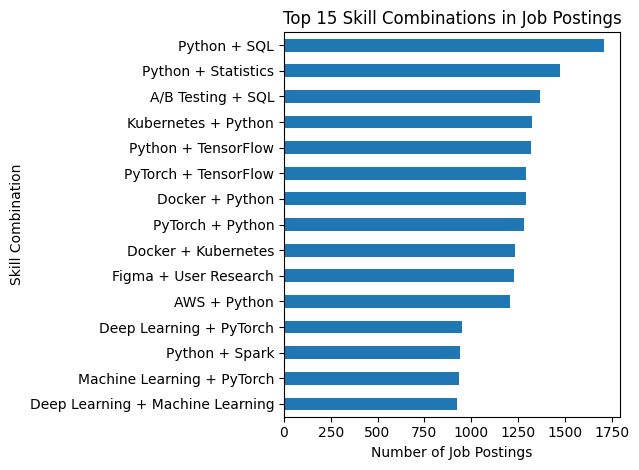

In [47]:
plt.figure(figsize=(10, 7))

top_skill_pairs.sort_values('Cooccurrence').plot(
    x='Skill_Pair',
    y='Cooccurrence',
    kind='barh',
    legend=False
)

plt.title('Top 15 Skill Combinations in Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill Combination')

plt.tight_layout()
plt.show()

In [48]:
top_skill_pairs[
    ['Skill_1', 'Skill_2', 'Cooccurrence']
].to_csv(
    "../data/top_skill_pairs.csv",
    index=False
)

print("Top skill pairs saved successfully.")

Top skill pairs saved successfully.


### 11. NLP Text Preprocessing

In [49]:
# Inspect job description examples

df['description'].head(5)

0    Join PolicyData Corp as a senior Data Scientis...
1    LearnEdge Systems is looking for a passionate ...
2    Join Keystone Public Analytics as a entry Prod...
3    Quantum Leap Digital is looking for a passiona...
4    As a director Backend Engineer at Fabricate AI...
Name: description, dtype: object

In [50]:
# Calculate description length

df['description_length'] = df['description'].str.len()

df['description_length'].describe()

count    15000.000000
mean       273.401933
std         40.382452
min        191.000000
25%        239.000000
50%        265.000000
75%        306.000000
max        394.000000
Name: description_length, dtype: float64

In [51]:
# Check for missing descriptions

df['description'].isna().sum()

np.int64(0)

In [52]:
# Display one complete job description

print(df.loc[0, 'description'])

Join PolicyData Corp as a senior Data Scientist and help us build product analytics infrastructure using Jupyter, Deep Learning, and Python. We value technical excellence and foster an inclusive environment where everyone can thrive.
